# EDA - Laboratory Data

- **Nguồn:** `Dataset/Data/laboratory_data.csv`
- **Kích thước:** 12,009 dòng × 14 cột (13 chỉ số sinh hóa + 1 nhãn bệnh)
- **Nhãn:** Có cột `Disease` làm nhãn bệnh (9 lớp).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

FILE_PATH = r'D:\PYTHON\Dataset\Data\laboratory_data.csv'

In [2]:
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Has disease label:', 'Disease' in df.columns)
print('\nDtypes:')
print(df.dtypes)

df.head(5)

Shape: (12009, 14)
Columns: ['Gender', 'Age', 'Hemoglobin', 'RBC', 'WBC', 'AST (aspartate aminotransferase)', 'ALT (alanine aminotransferase)', 'Cholestrol', 'Spirometry', 'Creatinine', 'Glucose', 'Lipase', 'Troponin', 'Disease']
Has disease label: True

Dtypes:
Gender                                  str
Age                                   int64
Hemoglobin                            int64
RBC                                 float64
WBC                                   int64
AST (aspartate aminotransferase)      int64
ALT (alanine aminotransferase)        int64
Cholestrol                            int64
Spirometry                          float64
Creatinine                          float64
Glucose                               int64
Lipase                                int64
Troponin                            float64
Disease                                 str
dtype: object


,Gender,Age,Hemoglobin,RBC,WBC,AST (aspartate aminotransferase),ALT (alanine aminotransferase),Cholestrol,Spirometry,Creatinine,Glucose,Lipase,Troponin,Disease
0,Male,59,6,1.20,6220,26,22,227,4.75,0.90,96,97,0.02,Anemia
1,Male,71,40,20.00,6636,18,27,220,3.93,1.03,94,82,0.04,Asthma
2,Female,22,14,3.55,18314,21,30,224,3.93,1.17,70,101,0.00,Infection
3,Male,53,16,4.95,9931,45,62,205,3.58,0.81,82,108,0.03,Liver Disease
4,Male,77,16,3.96,7088,29,25,217,3.20,1.70,97,107,0.04,Liver Disease


In [3]:
# Kiểm tra dữ liệu và missing values
missing = df.isnull().sum()
missing_sum = missing.sum()

if missing_sum == 0:
    print('Không có missing values.')
else:
    print(f'Tổng missing values: {missing_sum}')
    print(missing[missing > 0])

Không có missing values.


In [4]:
# Kiểm tra trùng lặp
dup_rows = df.duplicated().sum()
print(f'Số hàng trùng lặp: {dup_rows}')
if dup_rows > 0:
    print(df[df.duplicated(keep=False)].head())

Số hàng trùng lặp: 0


In [5]:
# Kiểm tra giá trị vô lý
bounds = {
    'Age': (0, 120),
    'Hemoglobin': (3, 25),
    'RBC': (1, 10),
    'WBC': (500, 100000),
    'AST (aspartate aminotransferase)': (0, 1000),
    'ALT (alanine aminotransferase)': (0, 1000),
    'Cholestrol': (50, 600),
    'Spirometry': (0, 8),
    'Creatinine': (0.1, 15),
    'Glucose': (20, 500),
    'Lipase': (0, 5000),
    'Troponin': (0, 50)
}

invalid_counts = {}
for col, (low, high) in bounds.items():
    if col in df.columns:
        invalid = df[(df[col] < low) | (df[col] > high)]
        invalid_counts[col] = len(invalid)

print('Số giá trị vô lý theo cột:')
for col, count in invalid_counts.items():
    print(f'  {col}: {count}')

total_invalid = sum(invalid_counts.values())
print(f'\nTổng giá trị vô lý: {total_invalid}')

Số giá trị vô lý theo cột:
  Age: 0
  Hemoglobin: 35
  RBC: 2538
  WBC: 0
  AST (aspartate aminotransferase): 0
  ALT (alanine aminotransferase): 0
  Cholestrol: 0
  Spirometry: 0
  Creatinine: 0
  Glucose: 0
  Lipase: 0
  Troponin: 0

Tổng giá trị vô lý: 2573


Số lớp bệnh: 9
Disease
Anemia                    2979
Heart attack              1555
Kidney Disease            1341
Diabetics                 1251
Infection                 1176
Liver Disease             1162
Asthma                     955
Pancreatitis               893
Cardiovascular disease     697
Name: count, dtype: int64


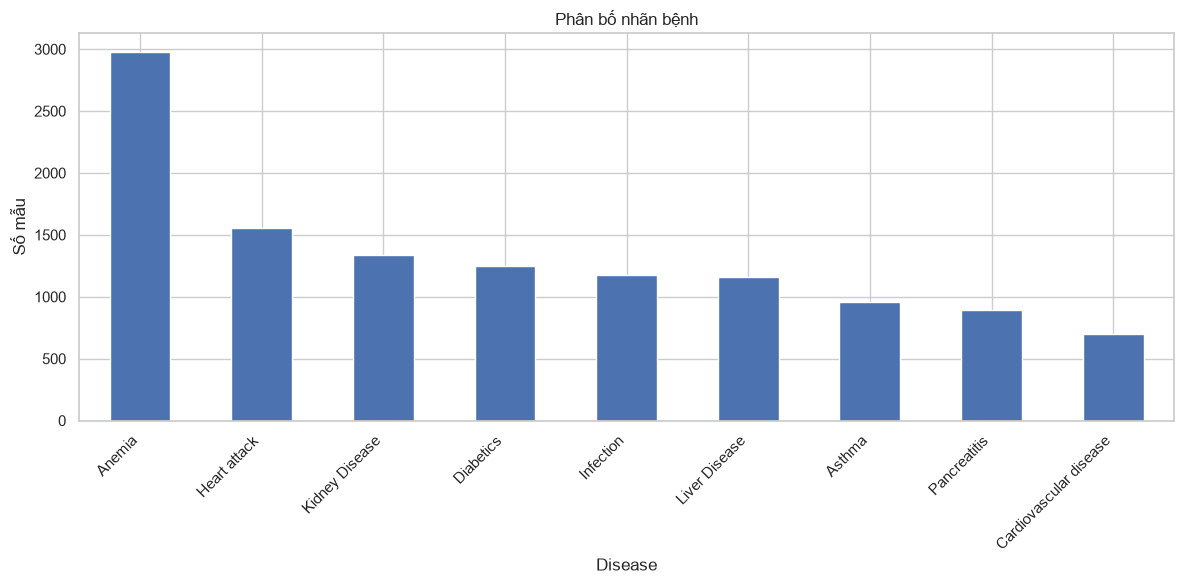

In [6]:
# Phân bố nhãn bệnh (diseases)
label_counts = df['Disease'].value_counts()
print('Số lớp bệnh:', label_counts.shape[0])
print(label_counts)

plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.title('Phân bố nhãn bệnh')
plt.ylabel('Số mẫu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

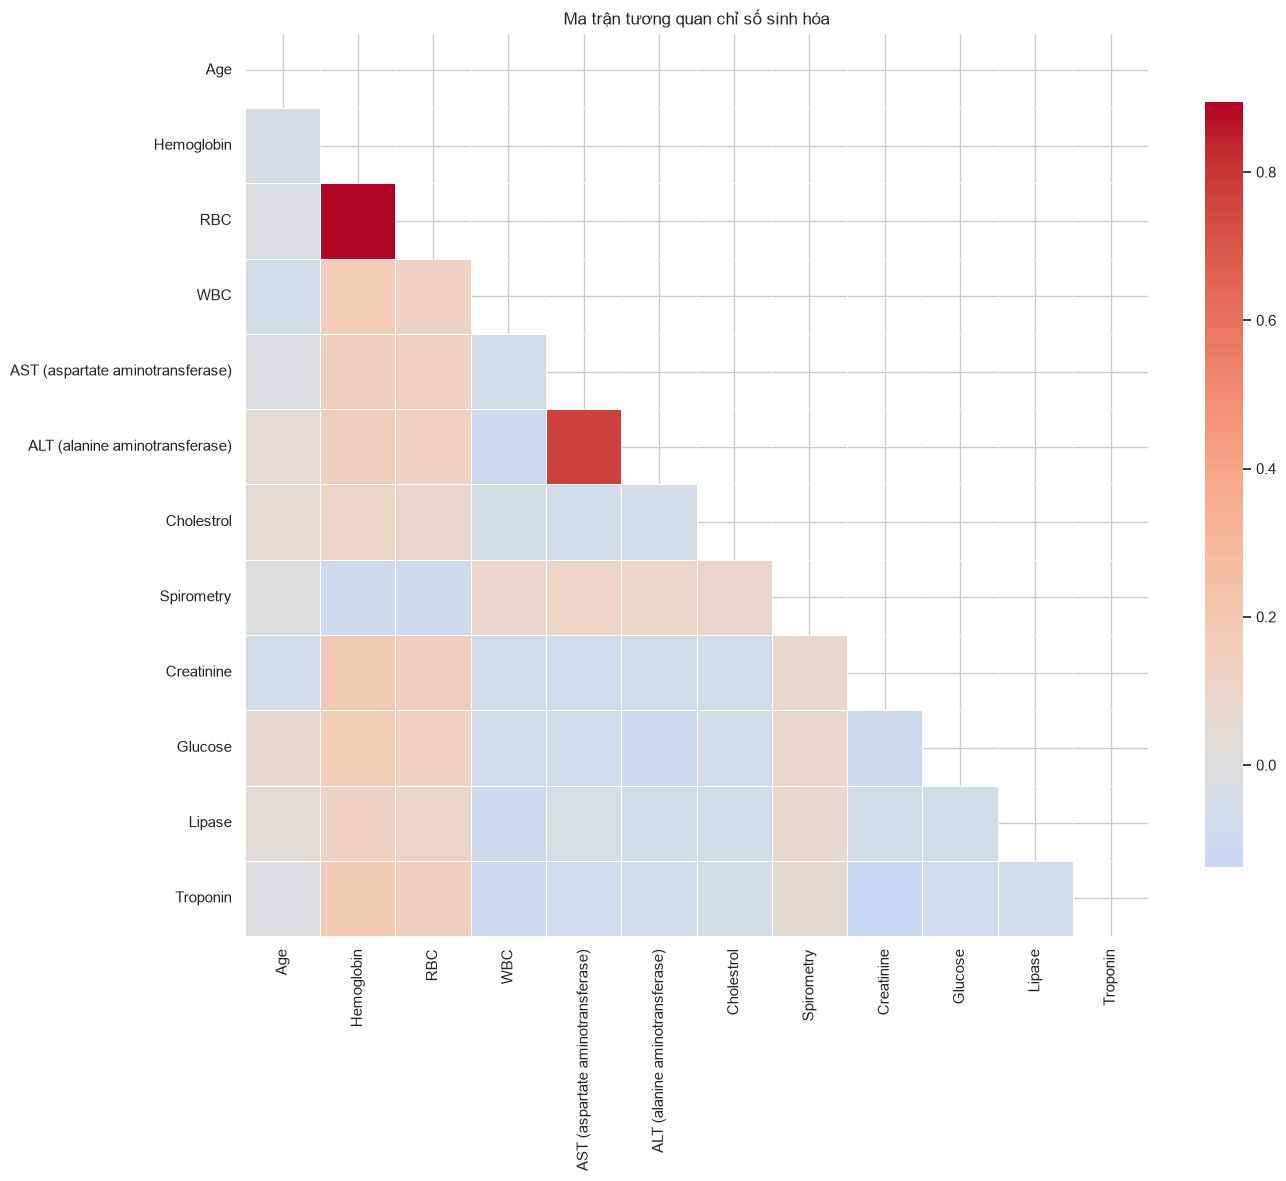

In [7]:
# Ma trận tương quan
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Ma trận tương quan chỉ số sinh hóa')
plt.tight_layout()
plt.show()

- **Missing values:** 0 — toàn bộ dữ liệu không có giá trị thiếu.
- **Trùng lặp:** 0 hàng trùng lặp hoàn toàn.
- **Giá trị vô lý:** Có một số giá trị nằm ngoài khoảng sinh học hợp lý (ví dụ: Hemoglobin max 50, RBC max 34, WBC max 27901). Cần kiểm tra lại các bản ghi có giá trị bất thường này.
- **Phân bố nhãn:** Lớp `Anemia` chiếm tỷ trọng cao nhất (~2,979 mẫu), các lớp còn lại dao động từ 697 (`Cardiovascular disease`) đến 1,555 (`Heart attack`). Tập dữ liệu có xu hướng lệch nhẹ về lớp đa số.
- **Ma trận tương quan:** Cần kiểm tra các cặp chỉ số có tương quan cao (ví dụ: AST-ALT, Creatinine-Glucose) để tránh đa cộng tuyến khi xây dựng mô hình.